<a href="https://colab.research.google.com/github/jamie07262/INFO-3608-PROJECT/blob/main/XGBoostWithNewDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import requests
import re
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss
import matplotlib.pyplot as plt

In [45]:
import os
import requests

# GitHub API URL for the directory
api_url = "https://api.github.com/repos/jamie07262/INFO-3608-PROJECT/contents/data/processed"

# Create local directory
os.makedirs("processed", exist_ok=True)

# Get list of files from GitHub API
response = requests.get(api_url)
if response.status_code == 200:
    files = response.json()
    for file in files:
        if file['name'].endswith('.csv'):
            download_url = file['download_url']
            r = requests.get(download_url)
            with open(f"processed/{file['name']}", "wb") as f:
                f.write(r.content)
            print(f"Downloaded: {file['name']}")
else:
    print(f"Failed to access API: {response.status_code}")

print("All CSV files downloaded.")

Downloaded: Features.csv
Downloaded: NewFeaturesForPredictions.csv
Downloaded: Predictions.csv
All CSV files downloaded.


In [46]:
df = pd.read_csv("processed/NewFeaturesForPredictions.csv")
df_features = df.copy()

Season 0    2003
1    2003
2    2003
Name: Season, dtype: int64
T1TeamID 0    1421
1    1112
2    1113
Name: T1TeamID, dtype: int64
T2TeamID 0    1411
1    1436
2    1272
Name: T2TeamID, dtype: int64
T1AverageScore 0    69.615326
1    84.511905
2    75.344828
Name: T1AverageScore, dtype: float64
T2AverageScore 0    72.533333
1    67.255172
2    74.210728
Name: T2AverageScore, dtype: float64
PointDifference 0     7.111111
1    29.000000
2    13.000000
Name: PointDifference, dtype: float64
T1Seed 0    16
1     1
2    10
Name: T1Seed, dtype: int64
T2Seed 0    16
1    16
2     7
Name: T2Seed, dtype: int64
SeedDifference 0     0
1    15
2    -3
Name: SeedDifference, dtype: int64
T1Rating 0    1004.511285
1    1428.100063
2    1169.181611
Name: T1Rating, dtype: float64
T2Rating 0    1006.068840
1    1163.408934
2    1344.907733
Name: T2Rating, dtype: float64
RatingDifference 0     -1.557555
1    264.691130
2   -175.726122
Name: RatingDifference, dtype: float64
T1Grade 0    -3.099741
1    27.

Holdout Season: 2003
Season 2003: 1.0 0.1407694821673834 0.0
Holdout Season: 2004
Season 2004: 1.0 0.1407694821673834 0.0
Holdout Season: 2005
Season 2005: 1.0 0.1407694821673834 0.0
Holdout Season: 2006
Season 2006: 1.0 0.1407693449385159 0.0
Holdout Season: 2007
Season 2007: 1.0 0.1407693449385159 0.0
Holdout Season: 2008
Season 2008: 1.0 0.1407693449385159 0.0
Holdout Season: 2009
Season 2009: 1.0 0.1407693449385159 0.0
Holdout Season: 2010
Season 2010: 1.0 0.1407693449385159 0.0
Holdout Season: 2011
Season 2011: 1.0 0.1407693449385159 0.0
Holdout Season: 2012
Season 2012: 1.0 0.1407693449385159 0.0
Holdout Season: 2013
Season 2013: 1.0 0.1407693449385159 0.0
Holdout Season: 2014
Season 2014: 1.0 0.1407693449385159 0.0
Holdout Season: 2015
Season 2015: 1.0 0.14076931063130962 0.0
Holdout Season: 2016
Season 2016: 1.0 0.1407692420168852 0.0
Holdout Season: 2017
Season 2017: 1.0 0.14076653175089882 0.0
Holdout Season: 2018
Season 2018: 1.0 0.14076653175089882 0.0
Holdout Season: 2019


,Season,Accuracy,LogLoss,Brier Score
0,2003,1.000000,0.140769,0.000000
1,2004,1.000000,0.140769,0.000000
2,2005,1.000000,0.140769,0.000000
3,2006,1.000000,0.140769,0.000000
4,2007,1.000000,0.140769,0.000000
5,2008,1.000000,0.140769,0.000000
6,2009,1.000000,0.140769,0.000000
7,2010,1.000000,0.140769,0.000000
8,2011,1.000000,0.140769,0.000000
9,2012,1.000000,0.140769,0.000000



Average Accuracy: 0.9996
Average Log Loss: 0.1415
Average Brier Score: 0.0004


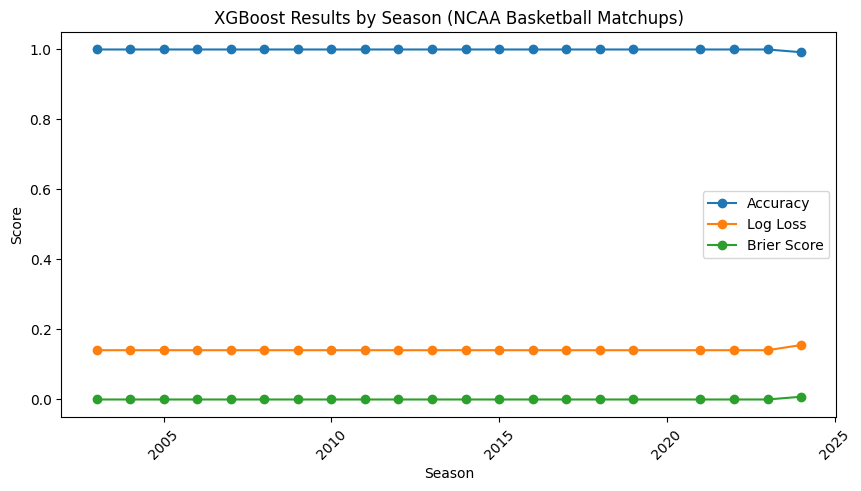

In [47]:
FEATURES = ['Season', 'T1TeamID', 'T2TeamID', 'T1AverageScore', 'T2AverageScore',
       'PointDifference', 'T1Seed', 'T2Seed', 'SeedDifference', 'T1Rating',
       'T2Rating', 'RatingDifference', 'T1Grade', 'T2Grade', 'GradeDifference',
       'Divison',
            # 'DivisonLabel',
            # 'Win',
            # 'WinLabel',
       'T1AverageFGM',
       'T1AverageFGA', 'T1AverageFGM3', 'T1AverageFGA3', 'T1AverageFTM',
       'T1AverageFTA', 'T1AverageOR', 'T1AverageDR', 'T1AverageAst',
       'T1AverageTO', 'T1AverageStl', 'T1AverageBlk', 'T1AveragePF',
       'T1AverageOpponentScore', 'T1AverageOpponentFGM',
       'T1AverageOpponentFGA', 'T1AverageOpponentFGM3',
       'T1AverageOpponentFGA3', 'T1AverageOpponentFTM', 'T1AverageOpponentFTA',
       'T1AverageOpponentOR', 'T1AverageOpponentDR', 'T1AverageOpponentAst',
       'T1AverageOpponentTO', 'T1AverageOpponentStl', 'T1AverageOpponentBlk',
       'T1AverageOpponentPF', 'T1AveragePointDifference', 'T2AverageFGM',
       'T2AverageFGA', 'T2AverageFGM3', 'T2AverageFGA3', 'T2AverageFTM',
       'T2AverageFTA', 'T2AverageOR', 'T2AverageDR', 'T2AverageAst',
       'T2AverageTO', 'T2AverageStl', 'T2AverageBlk', 'T2AveragePF',
       'T2AverageOpponentScore', 'T2AverageOpponentFGM',
       'T2AverageOpponentFGA', 'T2AverageOpponentFGM3',
       'T2AverageOpponentFGA3', 'T2AverageOpponentFTM', 'T2AverageOpponentFTA',
       'T2AverageOpponentOR', 'T2AverageOpponentDR', 'T2AverageOpponentAst',
       'T2AverageOpponentTO', 'T2AverageOpponentStl', 'T2AverageOpponentBlk',
       'T2AverageOpponentPF', 'T2AveragePointDifference']
TARGET = "Win"

# Prepare data
x = df_features[FEATURES]
y = df_features[TARGET]
groups = df_features["Season"]
seasons = df_features["Season"].unique()

# Set up GroupKFold for cross-validation by season
gkf = GroupKFold(n_splits=len(seasons))

# Store results and models
cv_results = []
models = []


# Cross-validation loop
for season_idx, (train_index, test_index) in enumerate(gkf.split(x, y, groups)):
    holdout_season = seasons[season_idx]
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Define model
    model = xgb.XGBRegressor(
        eval_metric="logloss",
        n_estimators = 1337,
        learning_rate=0.001,
    )

    holdout_season = seasons[season_idx]
    print(f"Holdout Season: {holdout_season}")

    # Train model
    model.fit(
        x_train,
        y_train,
        eval_set=[(x_test, y_test)],
        verbose = 0,
    )

    # Predict probabilities and class labels
    y_pred = model.predict(x_test)
    score_ll = log_loss(y_test, y_pred)
    y_pred = y_pred > 0.5

    # Evaluate performance
    accuracy = accuracy_score(y_test, y_pred)

    brier_score = brier_score_loss(y_test, y_pred)

    # Store results
    cv_results.append({
        "Season": holdout_season,
        "Accuracy": accuracy,
        "LogLoss": score_ll,
        "Brier Score": brier_score,
    })

    season_idx += 1
    print(f"Season {holdout_season}: {accuracy} {score_ll} {brier_score}")

    models.append(model)

# Display cross-validation results
df_cv_results = pd.DataFrame(cv_results)
display(df_cv_results)
print(f"\nAverage Accuracy: {df_cv_results['Accuracy'].mean():.4f}")
print(f"Average Log Loss: {df_cv_results['LogLoss'].mean():.4f}")
print(f"Average Brier Score: {df_cv_results['Brier Score'].mean():.4f}")

# Optional: Plot the results by season
plt.figure(figsize=(10, 5))
plt.plot(df_cv_results['Season'], df_cv_results['Accuracy'], marker='o', label='Accuracy')
plt.plot(df_cv_results['Season'], df_cv_results['LogLoss'], marker='o', label='Log Loss')
plt.plot(df_cv_results['Season'], df_cv_results['Brier Score'], marker='o', label='Brier Score')
plt.xlabel("Season")
plt.ylabel("Score")
plt.title("XGBoost Results by Season (NCAA Basketball Matchups)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [73]:
from itertools import product


teams = pd.unique(df[["T1TeamID", "T2TeamID"]].values.ravel())


matchups = set()
year = 2025

for t1, t2 in product(teams, repeat=2):
    if t1 != t2:
        low, high = sorted([t1, t2])
        matchups.add(f"{year}_{low}_{high}")


print(len(matchups))
matchups = list(matchups)
matchups = sorted(matchups)
print(matchups[121277])

121278
2025_3462_3465
